In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [85]:
import numpy as np
import pandas as pd

In [86]:
class SimpleLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        
        x_mean = X.mean()
        y_mean = y.mean()
        
        self.m = np.sum((X - x_mean)*(y - y_mean)) / \
                 np.sum((X - x_mean)**2)
                 
        self.b = y_mean - self.m * x_mean
        
        return self
    
    def predict(self, X):
        X = np.array(X)
        return self.m * X + self.b
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        return 1 - (ss_res / ss_tot)

In [87]:
df = pd.read_csv('placement.csv')

In [88]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X = df['cgpa'].values   # 1D array
y = df['package'].values

In [91]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

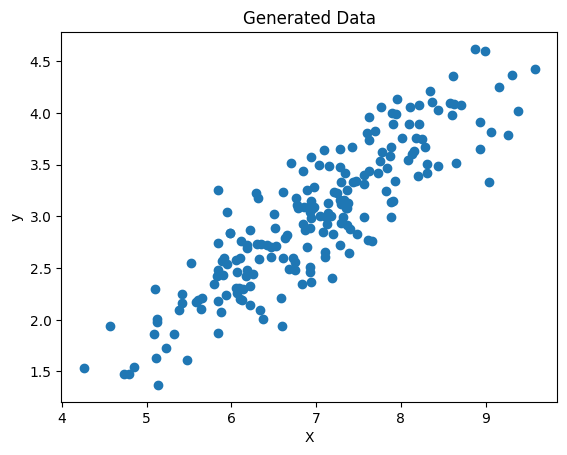

In [92]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()

In [93]:
model = SimpleLR()
model.fit(X_train, y_train)

print("Slope (m):", model.m)
print("Intercept (b):", model.b)

Slope (m): 0.557951973425072
Intercept (b): -0.8961119222429144


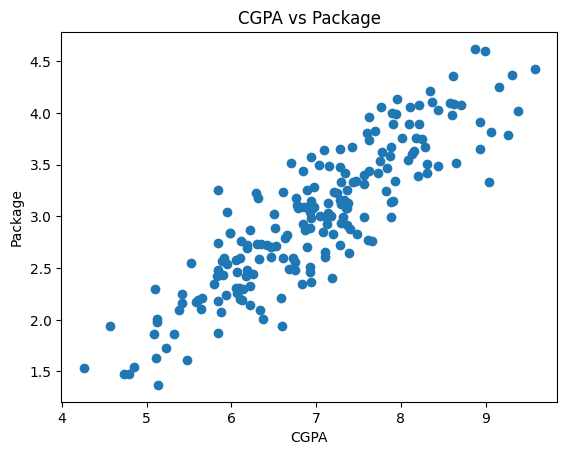

In [94]:
plt.scatter(X, y)
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("CGPA vs Package")
plt.show()

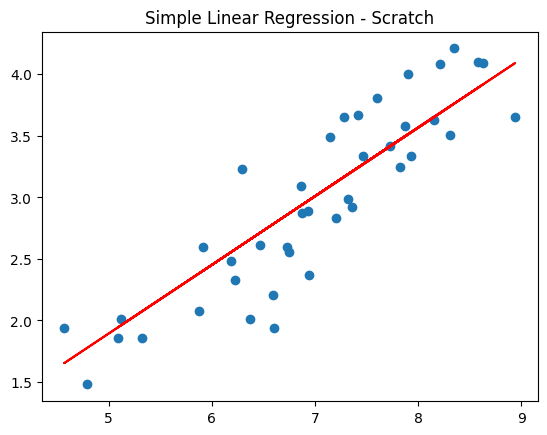

R2 Score (Scratch): 0.780730147510384


In [95]:
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color="red")
plt.title("Simple Linear Regression - Scratch")
plt.show()

print("R2 Score (Scratch):", model.score(X_test, y_test))

In [96]:
sk_model = LinearRegression()

# sklearn requires 2D input
sk_model.fit(X_train.reshape(-1,1), y_train)

sk_pred = sk_model.predict(X_test.reshape(-1,1))

print("Slope (sklearn):", sk_model.coef_[0])
print("Intercept (sklearn):", sk_model.intercept_)
print("R2 Score (sklearn):", r2_score(y_test, sk_pred))

Slope (sklearn): 0.557951973425072
Intercept (sklearn): -0.8961119222429144
R2 Score (sklearn): 0.780730147510384
